In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('cleaned_dataset.csv')

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,Ord200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,Trk37947903,7,Save10,Instagram,2853.10
1,Ord200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,Trk91186779,3,Save10,Referral,302.70
2,Ord200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,Trk42903982,8,Freeship,Email,2753.40
3,Ord200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,Trk62788070,5,Save10,Facebook,273.19
4,Ord200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,Trk29241424,8,Save10,Email,2504.04


In [4]:
df.shape

(1200, 14)

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [6]:
df.dtypes

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

In [8]:
#check missing values
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [9]:
print(df.describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


In [11]:
print(df.median(numeric_only=True))

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


In [14]:
print("Product Trend ANALYSIS: ")

#most ordered Product
print(df["Product"].value_counts())

Product Trend ANALYSIS: 
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [17]:
print("Payment Method Analysis: ")

#most used payment methods
print(df["PaymentMethod"].value_counts())

Payment Method Analysis: 
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [18]:
print("order status analysis: ")

#order status distribution
print (df["OrderStatus"].value_counts())

order status analysis: 
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [20]:
print("\n========= OUTLIER DETECTION (IQR METHOD) =========")

# Checking outliers in TotalPrice
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower_limit) |
    (df["TotalPrice"] > upper_limit)
]

print("Number of outliers in TotalPrice:", len(outliers))


========= OUTLIER DETECTION (IQR METHOD) =========
Number of outliers in TotalPrice: 8


In [21]:
print("EDA completed successfully.")
print("The dataset statistics, trends, and outliers have been analyzed.")


========= FINAL OBSERVATIONS =========
EDA completed successfully.
The dataset statistics, trends, and outliers have been analyzed.


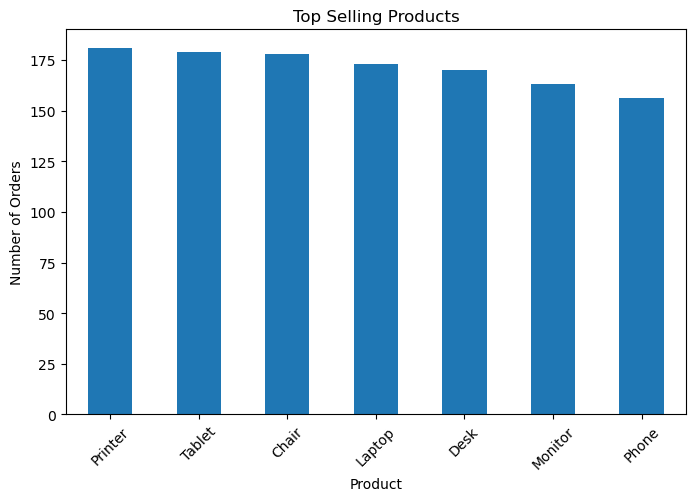

In [22]:
import matplotlib.pyplot as plt

df['Product'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

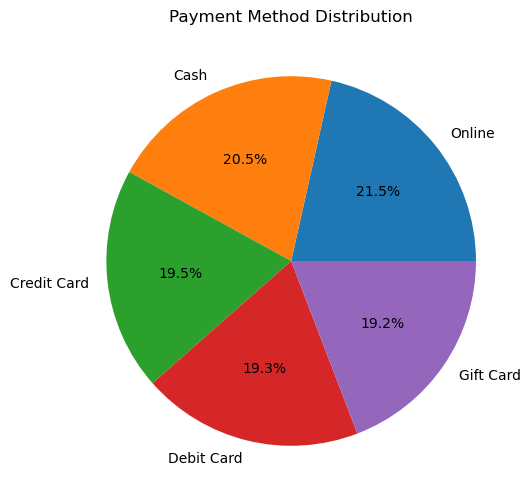

In [23]:
df['PaymentMethod'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

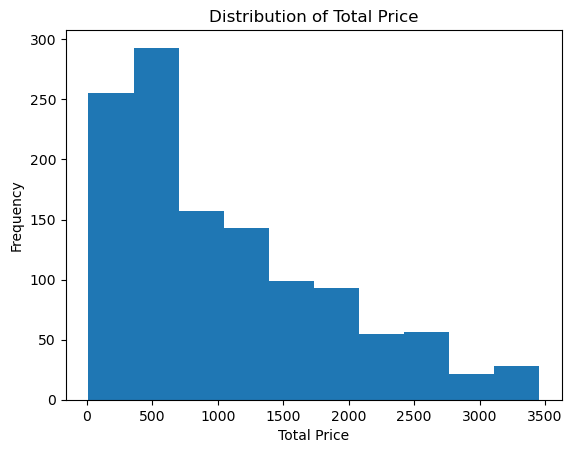

In [24]:
plt.hist(df['TotalPrice'], bins=10)
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.show()

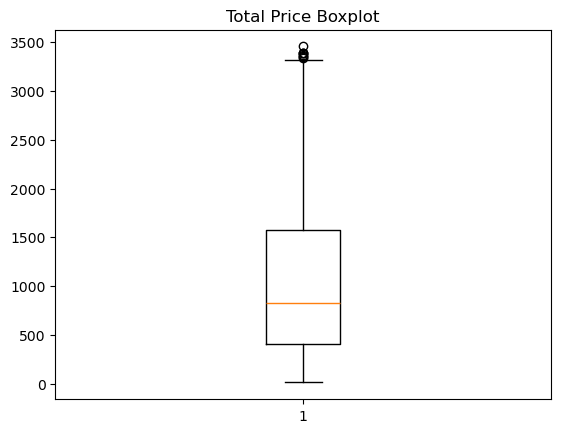

In [25]:
plt.boxplot(df['TotalPrice'])
plt.title('Total Price Boxplot')
plt.show()

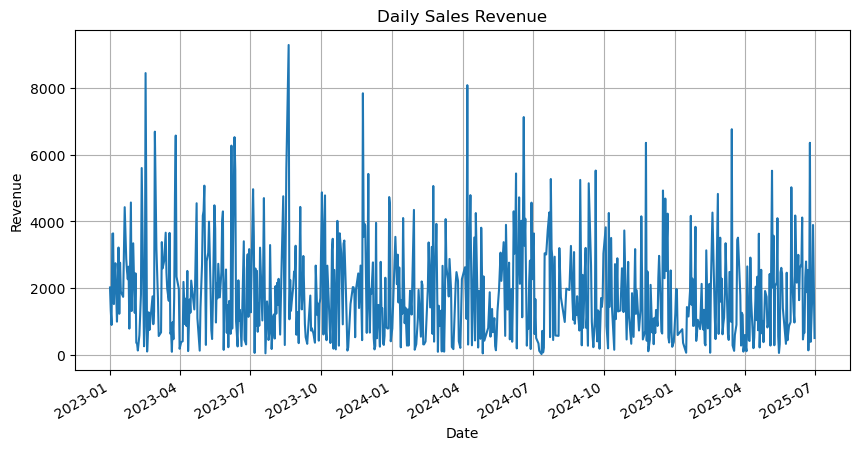

In [33]:
import matplotlib.pyplot as plt

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Group by Date and calculate total revenue
daily_sales = df.groupby('Date')['TotalPrice'].sum()

# Plot
plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title('Daily Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [32]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

## Conclusion

The dataset was successfully cleaned and analyzed using Python. Missing values were handled appropriately, and no duplicate records were found. Descriptive statistics, trend analysis, outlier detection, and data visualizations provided valuable insights into product sales, payment methods, order status, and revenue patterns. The dataset is now prepared for further analysis and machine learning applications.